In [22]:
# ============================================
# IMPORT REQUIRED LIBRARIES
# ============================================

import os
import time
import copy

import torch
import torch.nn as nn
import torch.optim as optim

import timm

import numpy as np

import matplotlib.pyplot as plt

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

from tqdm import tqdm

In [23]:
# ============================================
# DEVICE CONFIGURATION
# ============================================

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"
)

print("Using Device:", device)

Using Device: cuda


In [24]:
# ============================================
# ENHANCED DATASET PATHS
# ============================================

train_dir = "../dataset/enhanced_train"

val_dir = "../dataset/enhanced_val"

test_dir = "../dataset/enhanced_test"

In [25]:
# ============================================
# IMPROVED TRAIN TRANSFORMS
# ============================================

IMAGE_SIZE = 300

train_transforms = transforms.Compose([

    # Resize retinal images
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Medically safe augmentation
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),

    # Slight brightness/contrast variation
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    # Helps model generalize better
    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 1.0)
    ),

    transforms.ToTensor(),

    # ImageNet normalization
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================
# VALIDATION + TEST TRANSFORMS
# ============================================

val_test_transforms = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms Ready!")

Transforms Ready!


In [26]:
# ============================================
# LOAD DATASETS
# ============================================

train_dataset = datasets.ImageFolder(

    train_dir,

    transform=train_transforms
)

val_dataset = datasets.ImageFolder(

    val_dir,

    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(

    test_dir,

    transform=val_test_transforms
)

print("Train Size:", len(train_dataset))

print("Validation Size:", len(val_dataset))

print("Test Size:", len(test_dataset))

Train Size: 1050
Validation Size: 225
Test Size: 225


In [27]:
# ============================================
# CREATE DATALOADERS
# ============================================

BATCH_SIZE = 32

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=4,

    pin_memory=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=4,

    pin_memory=True
)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=4,

    pin_memory=True
)

print("DataLoaders Ready!")

DataLoaders Ready!


In [28]:
# ============================================
# FOCAL LOSS
# ============================================

import torch.nn.functional as F

class FocalLoss(nn.Module):

    def __init__(
        self,
        alpha=1,
        gamma=2,
        reduction='mean'
    ):

        super(FocalLoss, self).__init__()

        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):

        # Cross entropy with label smoothing
        ce_loss = F.cross_entropy(
            inputs,
            targets,
            reduction='none',
            label_smoothing=0.1
        )

        # Probability of correct class
        pt = torch.exp(-ce_loss)

        # Focal loss formula
        focal_loss = (
            self.alpha
            * (1 - pt) ** self.gamma
            * ce_loss
        )

        if self.reduction == 'mean':
            return focal_loss.mean()

        elif self.reduction == 'sum':
            return focal_loss.sum()

        else:
            return focal_loss

print("Focal Loss Ready!")

Focal Loss Ready!


In [29]:
# # # ============================================
# # # LOAD EFFICIENTNETB0
# # # ============================================

# # model = timm.create_model(

# #     "efficientnet_b0",

# #     pretrained=True,

# #     num_classes=5
# # )

# # # ============================================
# # # FREEZE BACKBONE
# # # ============================================

# # for param in model.parameters():

# #     param.requires_grad = False

# # # ============================================
# # # UNFREEZE CLASSIFIER ONLY
# # # ============================================

# # for param in model.classifier.parameters():

# #     param.requires_grad = True

# # model = model.to(device)

# # print("EfficientNetB0 Loaded!")

# # print("Backbone Frozen!")

# # print("Classifier Head Trainable!")


# # ============================================
# # LOAD EFFICIENTNETB0
# # ============================================

# model = timm.create_model(

#     "efficientnet_b0",

#     pretrained=True,

#     num_classes=5
# )

# # ============================================
# # FREEZE ALL LAYERS
# # ============================================

# for param in model.parameters():

#     param.requires_grad = False

# # ============================================
# # UNFREEZE LAST BLOCKS
# # ============================================

# for param in model.blocks[-2:].parameters():

#     param.requires_grad = True

# # ============================================
# # UNFREEZE CLASSIFIER
# # ============================================

# for param in model.classifier.parameters():

#     param.requires_grad = True

# model = model.to(device)

# print("Partial Fine Tuning Enabled!")

# ============================================
# LOAD EFFICIENTNET B2
# ============================================

from torchvision import models

model = models.efficientnet_b2(weights="DEFAULT")

# ============================================
# FREEZE EARLY LAYERS
# ============================================

for param in model.features.parameters():
    param.requires_grad = False

# ============================================
# UNFREEZE LAST BLOCKS
# ============================================

for param in model.features[-2:].parameters():
    param.requires_grad = True

# ============================================
# REPLACE CLASSIFIER
# ============================================

num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(

    nn.Dropout(0.4),

    nn.Linear(num_features, 5)
)

model = model.to(device)

# ============================================
# LOSS FUNCTION
# ============================================

criterion = FocalLoss(
    alpha=1,
    gamma=2
)

# ============================================
# OPTIMIZER
# ============================================

optimizer = torch.optim.AdamW(

    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),

    lr=5e-5,
    weight_decay=1e-4
)

# ============================================
# LEARNING RATE SCHEDULER
# ============================================

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)

print("EfficientNetB2 Model Ready!")

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to C:\Users\01may/.cache\torch\hub\checkpoints\efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:04<00:00, 8.47MB/s]


EfficientNetB2 Model Ready!


In [30]:
# # ============================================
# # LOSS FUNCTION
# # ============================================

# criterion = nn.CrossEntropyLoss()

# # ============================================
# # OPTIMIZER
# # ============================================

# optimizer = optim.AdamW(

#     filter(
#         lambda p: p.requires_grad,
#         model.parameters()
#     ),

#     lr=1e-3
# )

# # ============================================
# # LEARNING RATE SCHEDULER
# # ============================================

# scheduler = optim.lr_scheduler.ReduceLROnPlateau(

#     optimizer,

#     mode="min",

#     patience=3,

#     factor=0.5
# )

# print("Frozen Backbone Optimizer Ready!")


# ============================================
# LOSS FUNCTION
# ============================================

criterion = nn.CrossEntropyLoss()

# ============================================
# OPTIMIZER
# ============================================

optimizer = optim.AdamW(

    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),

    lr=1e-4
)

# ============================================
# LR SCHEDULER
# ============================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    patience=3,

    factor=0.5
)

print("Fine Tuning Optimizer Ready!")

Fine Tuning Optimizer Ready!


In [31]:
# ============================================
# MIXED PRECISION TRAINING
# ============================================

scaler = torch.amp.GradScaler("cuda")

print("AMP Mixed Precision Enabled!")

AMP Mixed Precision Enabled!


In [32]:
# ============================================
# TRAINING CONFIGURATION
# ============================================

NUM_EPOCHS = 100

EARLY_STOPPING_PATIENCE = 15

best_val_loss = float("inf")

patience_counter = 0

# Store metrics
train_losses = []

val_losses = []

train_accuracies = []

val_accuracies = []

print("Training Configuration Ready!")

Training Configuration Ready!


In [33]:
# ============================================
# TRAINING FUNCTION
# ============================================

def train_one_epoch(model, loader):

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, labels in progress_bar:

        # Move to GPU
        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        # Mixed precision
        with torch.amp.autocast("cuda"):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        # Backpropagation
        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        # Statistics
        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [34]:
# ============================================
# VALIDATION FUNCTION
# ============================================

def validate_one_epoch(model, loader):

    model.eval()

    running_loss = 0.0

    correct = 0

    total = 0

    with torch.no_grad():

        progress_bar = tqdm(
            loader,
            desc="Validation",
            leave=False
        )

        for images, labels in progress_bar:

            # Move to GPU
            images = images.to(device)

            labels = labels.to(device)

            with torch.amp.autocast("cuda"):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

            # Statistics
            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [35]:
# ============================================
# MAIN TRAINING LOOP
# ============================================

print("Starting EfficientNetB2 Training...\n")

start_time = time.time()

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")

    # ========================================
    # TRAINING
    # ========================================

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    # ========================================
    # VALIDATION
    # ========================================

    val_loss, val_acc = validate_one_epoch(
        model,
        val_loader
    )

    # ========================================
    # STORE METRICS
    # ========================================

    train_losses.append(train_loss)

    val_losses.append(val_loss)

    train_accuracies.append(train_acc)

    val_accuracies.append(val_acc)

    # ========================================
    # DISPLAY METRICS
    # ========================================

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Train Accuracy: {train_acc:.2f}%")

    print(f"Validation Loss: {val_loss:.4f}")

    print(f"Validation Accuracy: {val_acc:.2f}%")

    # ========================================
    # LEARNING RATE SCHEDULER
    # ========================================

    scheduler.step(val_loss)

    # ========================================
    # SAVE BEST MODEL
    # ========================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        patience_counter = 0

        torch.save(

            model.state_dict(),

            "../models/efficientnet/best_efficientnet_b2.pth"
        )

        print("Best Model Saved!")

    else:

        patience_counter += 1

        print(
            f"No Improvement Count: {patience_counter}"
        )

    # ========================================
    # EARLY STOPPING
    # ========================================

    if patience_counter >= EARLY_STOPPING_PATIENCE:

        print("\nEarly Stopping Triggered!")

        break

# ============================================
# TRAINING COMPLETE
# ============================================

end_time = time.time()

total_time = (end_time - start_time) / 60

print(f"\nTraining Completed!")

print(f"Total Training Time: {total_time:.2f} Minutes")

Starting EfficientNetB2 Training...


Epoch [1/100]


Train Loss: 1.4856
Train Accuracy: 37.33%
Validation Loss: 1.3793
Validation Accuracy: 50.67%
Best Model Saved!

Epoch [2/100]


Train Loss: 1.2558
Train Accuracy: 53.90%
Validation Loss: 1.1978
Validation Accuracy: 54.22%
Best Model Saved!

Epoch [3/100]


Train Loss: 1.1174
Train Accuracy: 56.29%
Validation Loss: 1.1072
Validation Accuracy: 57.78%
Best Model Saved!

Epoch [4/100]


Train Loss: 1.0159
Train Accuracy: 58.86%
Validation Loss: 1.0299
Validation Accuracy: 61.78%
Best Model Saved!

Epoch [5/100]


...

Train Loss: 0.3889
Train Accuracy: 87.05%
Validation Loss: 0.7920
Validation Accuracy: 69.78%
No Improvement Count: 11

Epoch [33/100]


Train Loss: 0.4027
Train Accuracy: 85.90%
Validation Loss: 0.7871
Validation Accuracy: 71.11%
No Improvement Count: 12

Epoch [34/100]


Train Loss: 0.3724
Train Accuracy: 87.71%
Validation Loss: 0.8010
Validation Accuracy: 70.22%
No Improvement Count: 13

Epoch [35/100]


Train Loss: 0.3760
Train Accuracy: 87.33%
Validation Loss: 0.7747
Validation Accuracy: 70.22%
No Improvement Count: 14

Epoch [36/100]


Train Loss: 0.3699
Train Accuracy: 88.00%
Validation Loss: 0.7988
Validation Accuracy: 70.67%
No Improvement Count: 15

Early Stopping Triggered!

Training Completed!
Total Training Time: 29.66 Minutes


In [52]:
# ============================================
# RETINAL SAFE TEST TIME AUGMENTATION
# ============================================

def tta_predict(model, image_tensor, device):

    model.eval()

    predictions = []

    with torch.no_grad():

        # ============================================
        # ORIGINAL IMAGE
        # ============================================

        output = model(image_tensor)

        predictions.append(
            torch.softmax(output, dim=1)
        )

        # ============================================
        # HORIZONTAL FLIP ONLY
        # ============================================

        flipped = torch.flip(
            image_tensor,
            dims=[3]
        )

        output = model(flipped)

        predictions.append(
            torch.softmax(output, dim=1)
        )

        # ============================================
        # AVERAGE PREDICTIONS
        # ============================================

        mean_prediction = torch.mean(
            torch.stack(predictions),
            dim=0
        )

    return mean_prediction

In [53]:
# # ============================================
# # LOAD BEST MODEL
# # ============================================

# model.load_state_dict(

#     torch.load(

#         "../models/efficientnet/best_efficientnet_b0.pth",

#         map_location=device
#     )
# )

# model.eval()

# print("Best Model Loaded!")

# ============================================
# LOAD BEST MODEL
# ============================================

model.load_state_dict(

    torch.load(
        "../models/efficientnet/best_efficientnet_b2.pth"
    )
)

model.eval()

print("Best EfficientNetB2 Model Loaded!")

Best EfficientNetB2 Model Loaded!


In [54]:
# # ============================================
# # TEST EVALUATION
# # ============================================

# all_predictions = []

# all_labels = []

# correct = 0

# total = 0

# with torch.no_grad():

#     progress_bar = tqdm(
#         test_loader,
#         desc="Testing"
#     )

#     for images, labels in progress_bar:

#         images = images.to(device)

#         labels = labels.to(device)

#         outputs = model(images)

#         _, predicted = torch.max(
#             outputs,
#             1
#         )

#         total += labels.size(0)

#         correct += (
#             predicted == labels
#         ).sum().item()

#         all_predictions.extend(
#             predicted.cpu().numpy()
#         )

#         all_labels.extend(
#             labels.cpu().numpy()
#         )

# test_accuracy = 100 * correct / total

# print(f"\nTest Accuracy: {test_accuracy:.2f}%")

# ============================================
# TEST EVALUATION WITH TTA
# ============================================

from tqdm import tqdm

model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in tqdm(test_loader, desc="Testing"):

        images = images.to(device)
        labels = labels.to(device)

        batch_predictions = []

        # ============================================
        # TTA FOR EACH IMAGE
        # ============================================

        for i in range(images.size(0)):

            single_image = images[i].unsqueeze(0)

            prediction = tta_predict(
                model,
                single_image,
                device
            )

            batch_predictions.append(prediction)

        outputs = torch.cat(batch_predictions, dim=0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        # Store predictions
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ============================================
# FINAL TEST ACCURACY
# ============================================

test_accuracy = 100 * correct / total

print(f"\nTTA Test Accuracy: {test_accuracy:.2f}%")

Testing: 100%|██████████| 8/8 [00:14<00:00,  1.83s/it]


TTA Test Accuracy: 68.89%


In [55]:
# ============================================
# CLASSIFICATION REPORT
# ============================================

class_names = [

    "No DR",

    "Mild DR",

    "Moderate DR",

    "Severe DR",

    "Proliferative DR"
]

report = classification_report(

    all_labels,

    all_predictions,

    target_names=class_names
)

print(report)

                  precision    recall  f1-score   support

           No DR       0.88      0.96      0.91        45
         Mild DR       0.67      0.67      0.67        45
     Moderate DR       0.55      0.49      0.52        45
       Severe DR       0.67      0.78      0.72        45
Proliferative DR       0.64      0.56      0.60        45

        accuracy                           0.69       225
       macro avg       0.68      0.69      0.68       225
    weighted avg       0.68      0.69      0.68       225



In [ ]:
# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(

    all_labels,

    all_predictions
)

print(cm)

[[43  2  0  0  0]
 [ 5 30  7  0  3]
 [ 0  8 22  7  8]
 [ 0  2  5 35  3]
 [ 1  3  6 10 25]]


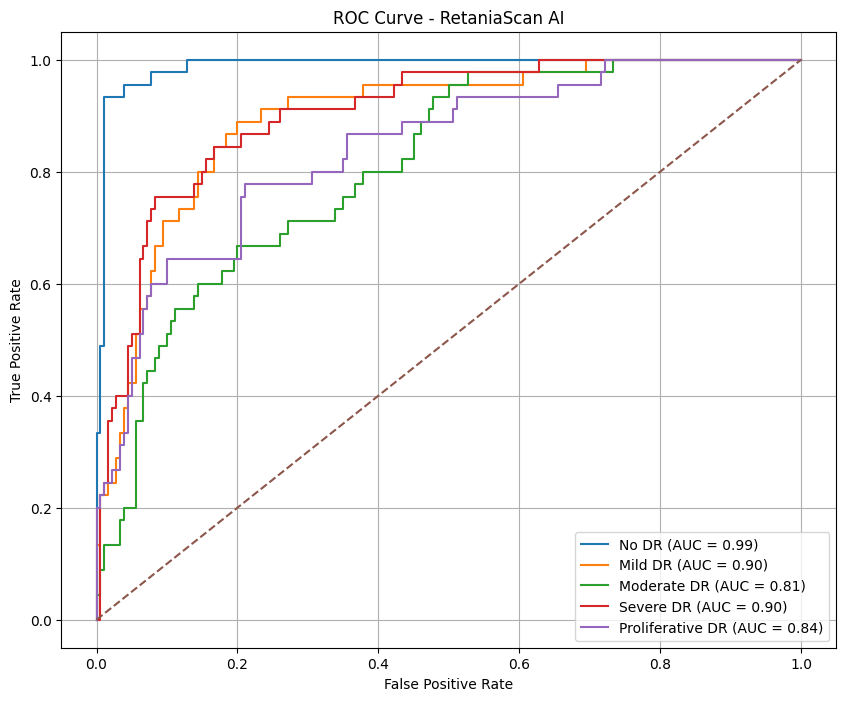


ROC Analysis Completed!


In [60]:
# ============================================
# ROC CURVE AND AUC ANALYSIS
# ============================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# CLASS NAMES
# ============================================

class_names = [
    "No DR",
    "Mild DR",
    "Moderate DR",
    "Severe DR",
    "Proliferative DR"
]

# ============================================
# STORE TRUE LABELS + PROBABILITIES
# ============================================

all_labels = []
all_probs = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        all_probs.extend(
            probabilities.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

# Convert to numpy
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# ============================================
# BINARIZE LABELS
# ============================================

binary_labels = label_binarize(
    all_labels,
    classes=[0,1,2,3,4]
)

# ============================================
# PLOT ROC CURVES
# ============================================

plt.figure(figsize=(10,8))

for i in range(5):

    fpr, tpr, _ = roc_curve(
        binary_labels[:, i],
        all_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(

        fpr,

        tpr,

        label=(
            f"{class_names[i]} "
            f"(AUC = {roc_auc:.2f})"
        )
    )

# ============================================
# RANDOM CLASSIFIER LINE
# ============================================

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

# ============================================
# PLOT SETTINGS
# ============================================

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - RetaniaScan AI"
)

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

print("\nROC Analysis Completed!")

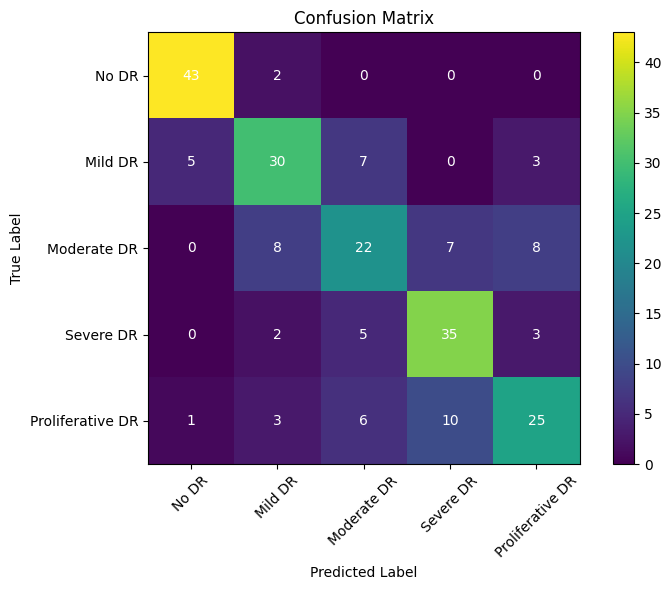

In [57]:
# ============================================
# VISUALIZE CONFUSION MATRIX
# ============================================

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(

    np.arange(len(class_names)),

    class_names,

    rotation=45
)

plt.yticks(

    np.arange(len(class_names)),

    class_names
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

# Display values
for i in range(len(class_names)):

    for j in range(len(class_names)):

        plt.text(

            j,

            i,

            cm[i, j],

            ha="center",

            va="center",

            color="white"
        )

plt.tight_layout()

plt.show()

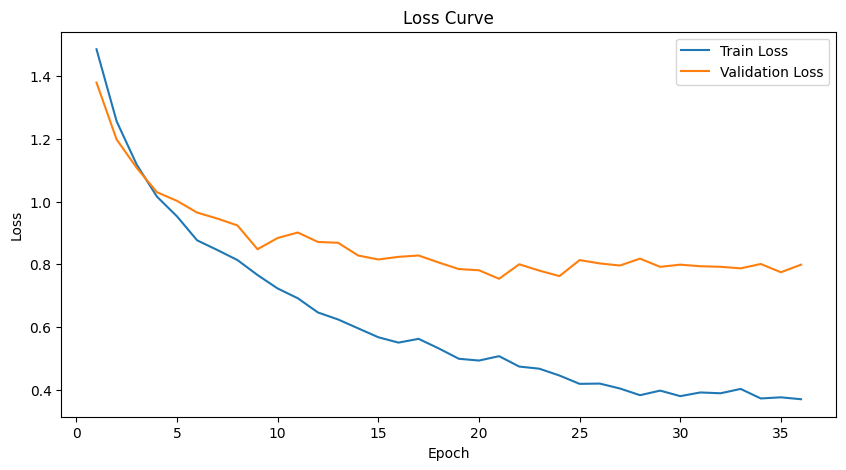

In [58]:
# ============================================
# LOSS CURVE
# ============================================

epochs_range = range(

    1,

    len(train_losses) + 1
)

plt.figure(figsize=(10, 5))

plt.plot(

    epochs_range,

    train_losses,

    label="Train Loss"
)

plt.plot(

    epochs_range,

    val_losses,

    label="Validation Loss"
)

plt.title("Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

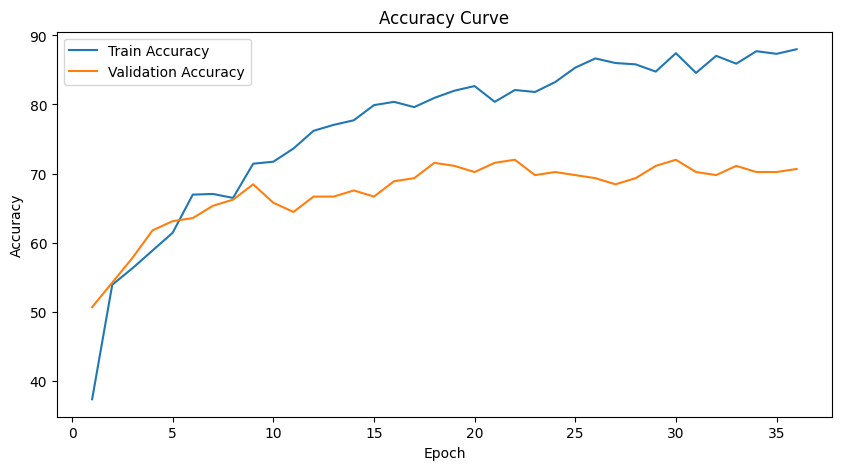

In [59]:
# ============================================
# ACCURACY CURVE
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(

    epochs_range,

    train_accuracies,

    label="Train Accuracy"
)

plt.plot(

    epochs_range,

    val_accuracies,

    label="Validation Accuracy"
)

plt.title("Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()